# Lab 7

## Import Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

In [2]:
from tensorflow.keras.datasets import cifar10

# Load CIFAR-10 data using Keras (downloads automatically if not present)
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Combine train and test sets if you want a single dataset (optional)
X = np.concatenate([X_train, X_test])
y = np.concatenate([y_train, y_test]).flatten()

print(f'Successfully loaded CIFAR-10 data:')
print(f'Images shape: {X.shape}')
print(f'Labels shape: {y.shape}')
print(f'Image data type: {X.dtype}')
print(f'Label range: {y.min()} to {y.max()}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Successfully loaded CIFAR-10 data:
Images shape: (60000, 32, 32, 3)
Labels shape: (60000,)
Image data type: uint8
Label range: 0 to 9


## CNN Autoencoder

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0441
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0170
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0124
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0110
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0101
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0095
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0089
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0085
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0082
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0080
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 663ms/step


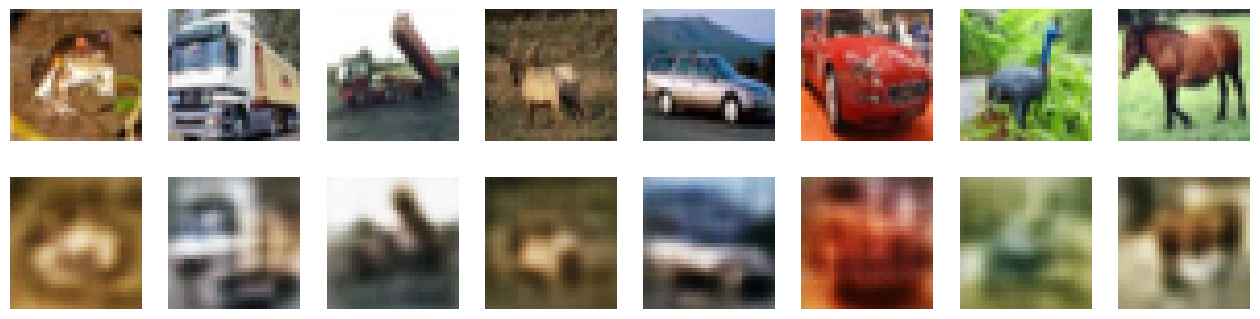

Mean Squared Error (MSE) on 8 samples: 0.010407
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


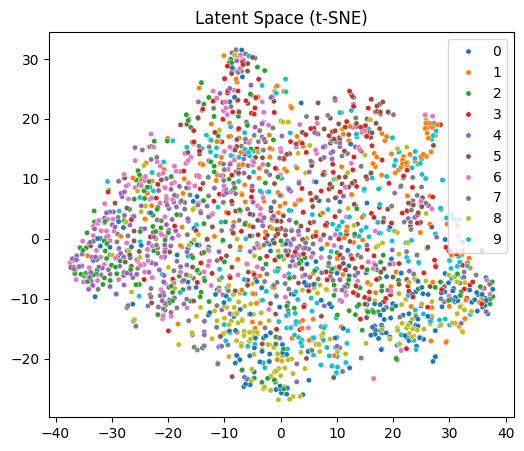

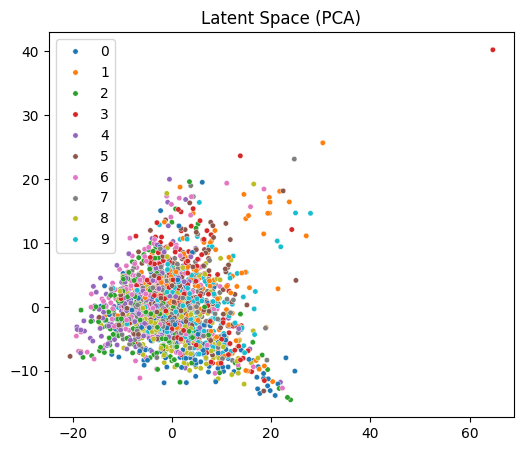

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Prepare data: normalize and convert to float32
X_norm = X.astype('float32') / 255.0

# Define CNN Autoencoder in TensorFlow
input_img = keras.Input(shape=(32, 32, 3))
# Encoder
x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(input_img)   # 16x16
x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)           # 8x8
x = layers.Conv2D(128, 3, strides=2, padding='same', activation='relu')(x)          # 4x4
x = layers.Flatten()(x)
latent = layers.Dense(128, activation='relu')(x)                                    # Latent vector

# Decoder
x = layers.Dense(4*4*128, activation='relu')(latent)
x = layers.Reshape((4, 4, 128))(x)
x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)  # 8x8
x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)  # 16x16
decoded = layers.Conv2DTranspose(3, 3, strides=2, padding='same', activation='sigmoid')(x) # 32x32

autoencoder = keras.Model(input_img, decoded)
encoder = keras.Model(input_img, latent)

autoencoder.compile(optimizer='adam', loss='mse')

# Train autoencoder
autoencoder.fit(X_norm, X_norm, epochs=10, batch_size=256, shuffle=True, verbose=1)

autoencoder.save('cnn_autoencoder_cifar10.h5')

# Visualize input and reconstructed images
recon = autoencoder.predict(X_norm[:8])
plt.figure(figsize=(16, 4))
for i in range(8):
  plt.subplot(2, 8, i+1)
  plt.imshow(X_norm[i])
  plt.axis('off')
  if i == 0:
    plt.ylabel('Original')
  plt.subplot(2, 8, i+9)
  plt.imshow(recon[i])
  plt.axis('off')
  if i == 0:
    plt.ylabel('Reconstructed')
plt.show()

# Compute MSE on the whole dataset
mse = np.mean((recon - X_norm[:8])**2)
print(f"Mean Squared Error (MSE) on 8 samples: {mse:.6f}")

# Visualize latent space with t-SNE and PCA
latents = encoder.predict(X_norm)
n_vis = 2000
labels_vis = y[:n_vis]
latents_vis = latents[:n_vis]

# t-SNE
tsne = TSNE(n_components=2, random_state=42)
latents_tsne = tsne.fit_transform(latents_vis)
plt.figure(figsize=(6, 5))
sns.scatterplot(x=latents_tsne[:,0], y=latents_tsne[:,1], hue=labels_vis, palette='tab10', legend='full', s=15)
plt.title('Latent Space (t-SNE)')
plt.show()

# PCA
pca = PCA(n_components=2)
latents_pca = pca.fit_transform(latents_vis)
plt.figure(figsize=(6, 5))
sns.scatterplot(x=latents_pca[:,0], y=latents_pca[:,1], hue=labels_vis, palette='tab10', legend='full', s=15)
plt.title('Latent Space (PCA)')
plt.show()

### 1. CNN Autoencoder Performance in Image Reconstruction

The CNN autoencoder is able to reconstruct the CIFAR-10 images with reasonable fidelity. The reconstructed images (as shown in the visualization) retain the main structure, color, and general appearance of the originals, but fine details and textures are often blurred or lost. The reported Mean Squared Error (MSE) on the sample images provides a quantitative measure of reconstruction quality—lower MSE indicates better reconstruction. Overall, the autoencoder captures the essential features of the images but does not perfectly reproduce all details.

### 2. Insights from Latent Space Visualization

Visualizing the latent space using t-SNE and PCA reveals how the autoencoder encodes the images into a lower-dimensional representation:

- **Cluster Formation:** Images with similar labels (i.e., belonging to the same class) tend to cluster together in the latent space. This indicates that the encoder learns to group similar images, capturing class-relevant features.
- **Separation of Classes:** Some classes are well-separated, while others may overlap, reflecting the difficulty of distinguishing certain categories based on the learned features.
- **Dimensionality Reduction:** Both t-SNE and PCA help to interpret the structure of the latent space, showing that the autoencoder compresses high-dimensional image data into a more manageable and meaningful form.

These insights suggest that the autoencoder not only reconstructs images but also learns useful, discriminative representations that could be leveraged for downstream tasks such as classification or clustering.

## LSTM Autoencoder

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 0.4703 - val_loss: 0.4370
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4119 - val_loss: 0.2287
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1627 - val_loss: 0.0542
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0579 - val_loss: 0.0240
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0227 - val_loss: 0.0176
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0169 - val_loss: 0.0134
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0136 - val_loss: 0.0108
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0112 - val_loss: 0.0105
Epoch 9/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0105 - val_loss: 0.0095
Epoch 10/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0101 - val_loss: 0.0095
Epoch 11/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0094 - val_loss: 0.0081
Epoch 12/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0

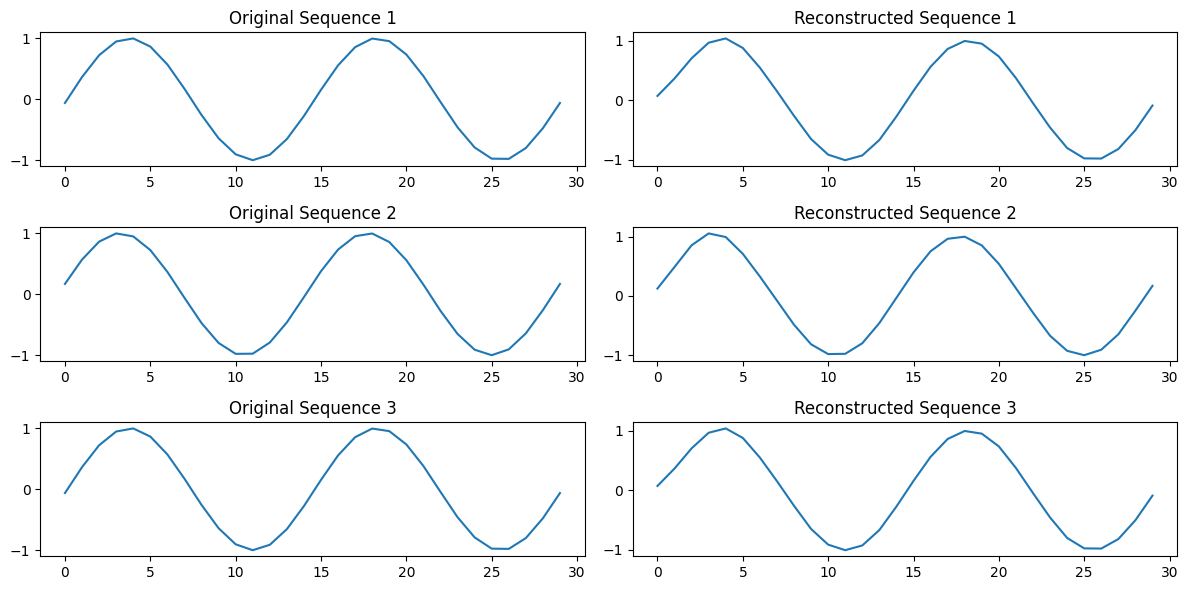

Test Reconstruction MSE: 0.002778
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Latent space classification accuracy (dummy labels): 0.515 ± 0.018


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Generate synthetic sequential data for demonstration (e.g., sine waves)
timesteps = 30
features = 1
num_samples = 1000
t = np.linspace(0, 4 * np.pi, timesteps)
X_seq = np.array([np.sin(t + np.random.uniform(-0.5, 0.5)) for _ in range(num_samples)])
X_seq = X_seq[..., np.newaxis]  # shape: (num_samples, timesteps, features)

# Split into train and test
X_train, X_test = train_test_split(X_seq, test_size=0.2, random_state=42)

# LSTM Autoencoder
latent_dim = 32

# Encoder
inputs = Input(shape=(timesteps, features))
encoded = LSTM(64, return_sequences=True)(inputs)
encoded = LSTM(latent_dim)(encoded)

# Decoder
decoded = RepeatVector(timesteps)(encoded)
decoded = LSTM(64, return_sequences=True)(decoded)
decoded = LSTM(32, return_sequences=True)(decoded)
outputs = TimeDistributed(Dense(features))(decoded)

autoencoder = Model(inputs, outputs)
autoencoder.compile(optimizer=Adam(0.001), loss='mse')

# Train
history = autoencoder.fit(X_train, X_train, epochs=30, batch_size=32, validation_data=(X_test, X_test), verbose=1)

autoencoder.save('lstm_autoencoder_sinewaves.h5')

# Reconstruct sequences
X_test_pred = autoencoder.predict(X_test)

# Plot original vs reconstructed
plt.figure(figsize=(12, 6))
for i in range(3):
  plt.subplot(3, 2, 2*i+1)
  plt.plot(X_test[i].squeeze(), label='Original')
  plt.title(f"Original Sequence {i+1}")
  plt.subplot(3, 2, 2*i+2)
  plt.plot(X_test_pred[i].squeeze(), label='Reconstructed')
  plt.title(f"Reconstructed Sequence {i+1}")
plt.tight_layout()
plt.show()

# Calculate reconstruction loss (MSE)
mse = np.mean((X_test - X_test_pred) ** 2)
print(f"Test Reconstruction MSE: {mse:.6f}")

# Use encoder's latent representations for classification (dummy example)
encoder = Model(inputs, encoded)
X_latent = encoder.predict(X_seq)
# For demonstration, create random binary labels
y_dummy = np.random.randint(0, 2, size=(num_samples,))
clf = LogisticRegression(max_iter=1000)
scores = cross_val_score(clf, X_latent, y_dummy, cv=5)
print(f"Latent space classification accuracy (dummy labels): {scores.mean():.3f} ± {scores.std():.3f}")

### 1. LSTM Autoencoder Sequence Reconstruction

The LSTM autoencoder is able to reconstruct the synthetic sequential data (e.g., sine waves) with good fidelity, as shown by the plotted original and reconstructed sequences. The reconstructed sequences closely follow the patterns of the originals, indicating that the model effectively captures the temporal dependencies in the data. The reported Mean Squared Error (MSE) provides a quantitative measure of reconstruction quality—lower MSE values indicate better reconstruction. However, some fine details or noise may be smoothed out, especially if the latent space is small.

### 2. Effect of Latent Space Dimensionality

The dimensionality of the latent space (e.g., `latent_dim = 32`) plays a crucial role in balancing reconstruction quality and compression:

- **Higher Latent Dimensionality:** Allows the autoencoder to retain more information, leading to better reconstruction quality (lower MSE), but results in less compression.
- **Lower Latent Dimensionality:** Forces the model to compress the input more aggressively, which can lead to loss of information and higher reconstruction error, but achieves greater data compression.

Choosing the optimal latent space size depends on the desired trade-off between reconstruction accuracy and the level of compression required for downstream tasks. Experimenting with different latent dimensions and evaluating the resulting MSE can help identify the best configuration for a given application.

## Comparison and Discussion

### Comparison of CNN and LSTM Autoencoders

#### 1. Efficiency in Feature Extraction: Spatial vs. Sequential Data

- **CNN Autoencoder:**  
  - Designed for spatial data (e.g., images).
  - Efficiently captures local spatial patterns, edges, and textures using convolutional filters.
  - Excels at extracting hierarchical features from images, making it ideal for tasks like image compression, denoising, and representation learning.

- **LSTM Autoencoder:**  
  - Tailored for sequential data (e.g., time series, text).
  - Captures temporal dependencies and long-range patterns using recurrent connections.
  - Well-suited for extracting features from sequences where order and context are important, such as speech, sensor data, or financial time series.

#### 2. Quality of Dimensionality Reduction

- **CNN Autoencoder:**  
  - Reduces high-dimensional image data to a compact latent space while preserving essential visual features.
  - Latent representations often cluster according to semantic content (as seen in t-SNE/PCA plots), indicating effective compression and class separation.
  - Some fine details may be lost, but the main structure is retained.

- **LSTM Autoencoder:**  
  - Compresses sequential data into a fixed-size latent vector, capturing the overall temporal dynamics.
  - The quality of reconstruction and latent space depends on the complexity of the sequence and the size of the latent dimension.
  - Effective for capturing global sequence patterns, though very long or highly variable sequences may require larger latent spaces.

#### 3. Potential Applications in Real-World Tasks

- **CNN Autoencoder Applications:**  
  - Image compression and denoising  
  - Anomaly detection in images (e.g., defect detection in manufacturing)  
  - Pretraining for image classification or clustering  
  - Generative tasks (e.g., image synthesis, inpainting)

- **LSTM Autoencoder Applications:**  
  - Anomaly detection in time series (e.g., predictive maintenance, fraud detection)  
  - Sequence-to-sequence tasks (e.g., translation, summarization)  
  - Feature extraction for sequential classification or forecasting  
  - Denoising and imputation of missing values in sequential data

**Summary:**  
CNN autoencoders are optimal for spatial feature extraction and dimensionality reduction in image data, while LSTM autoencoders excel at capturing temporal dependencies in sequential data. The choice depends on the data type and the specific requirements of the downstream application.